In [95]:
import pandas as pd
import os
raw_data_path = os.path.join("..", "data", "raw", "US-Exec_SOTU_2025.csv")
df_us = pd.read_csv(raw_data_path, encoding="latin1")
print("Columns in dataset:", df_us.columns)
print(df_us.head())

Columns in dataset: Index(['id', 'doc_count', 'filter_PolicySentence', 'date', 'oral_delivery',
       'outgoing', 'congress', 'president', 'pres_party', 'divided',
       'control_house', 'control_senate', 'year', 'month', 'day', 'source',
       'description', 'pap_majortopic', 'pap_subtopic', 'majortopic',
       'subtopic'],
      dtype='object')
    id  doc_count  filter_PolicySentence     date  oral_delivery  outgoing  \
0  1.0        1.0                    1.0  1/21/46            0.0       0.0   
1  2.0        2.0                    1.0  1/21/46            0.0       0.0   
2  3.0        3.0                    1.0  1/21/46            0.0       0.0   
3  4.0        4.0                    1.0  1/21/46            0.0       0.0   
4  5.0        5.0                    1.0  1/21/46            0.0       0.0   

   congress        president  pres_party  divided  ...  control_senate  \
0      79.0  Harry S. Truman       100.0      0.0  ...           100.0   
1      79.0  Harry S. Truman  

In [96]:
column_mapping = {
    "president": "speaker",
    "year": "year",
    "date": "date",
    "description": "text"
}
# Rename the columns
df_us_cleaned = df_us.rename(columns=column_mapping)
standard_cols = ['year', 'date', 'speaker', 'text']
df_us_cleaned = df_us_cleaned[[col for col in standard_cols if col in df_us_cleaned.columns]]
# clean up the text
df_us_cleaned['text'] = df_us_cleaned['text'].astype(str).str.strip()
df_us_cleaned = df_us_cleaned.dropna(subset=['text'])
output_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_cleaned.to_csv(output_path, index=False, encoding="utf-8")
print(f"Successfully cleaned and saved {len(df_us_cleaned)} speeches to {output_path}!")
df_us_cleaned = df_us_cleaned.dropna(subset=['text'])
output_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_cleaned.to_csv(output_path, index=False, encoding="utf-8")
print(f"Successfully cleaned and saved {len(df_us_cleaned)} speeches to {output_path}!")

Successfully cleaned and saved 26118 speeches to ..\data\clean\us_speeches_clean.csv!
Successfully cleaned and saved 26118 speeches to ..\data\clean\us_speeches_clean.csv!


In [97]:
import re
import os
import pandas as pd

us_speeches_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_speeches = pd.read_csv(us_speeches_path, encoding="utf-8")

import matplotlib.pyplot as plt

us_speeches_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_speeches = pd.read_csv(us_speeches_path, encoding="utf-8")

df_us_speeches = df_us_speeches.dropna(subset=['year']).copy()
df_us_speeches['year'] = df_us_speeches['year'].astype(int)
df_us_speeches['text'] = df_us_speeches['text'].astype(str)

YEAR_START, YEAR_END = 1946, 2015
df_us_filtered = df_us_speeches[(df_us_speeches['year'] >= YEAR_START) & (df_us_speeches['year'] <= YEAR_END)]

print(f"Analyzing US speeches from year {YEAR_START} to {YEAR_END}")

Analyzing US speeches from year 1946 to 2015


In [101]:
import importlib
import sys

sys.path.append("../src")
try:
    import keywords
    importlib.reload(keywords)
    from keywords import CATEGORY_KEYWORDS
except ModuleNotFoundError:
    CATEGORY_KEYWORDS = globals().get("CATEGORY_KEYWORDS", {})

print(CATEGORY_KEYWORDS)

{'defense': {'SDF', 'self-defence', 'north korea', 'missile', 'russia', 'troops', 'navy', 'deterrence', 'alliance', 'military base', 'army', 'security council', 'china', 'threat', 'defense', 'defence', 'military', 'article 9', 'armed forces', 'self-defense'}, 'economy': {'wage', 'financial contributions', 'employment', 'interest rate', 'growth', 'economy', 'finance', 'investment', 'budget', 'export', 'exchange rate', 'economic growth', 'import', 'trade', 'gdp', 'inflation', 'business', 'economic', 'tax', 'company', 'market', 'deficit', 'industry', 'stimulus', 'Bank of Japan', 'financial'}, 'nuclear': {'radiation', 'non-proliferation', 'atomic', 'plutonium', 'atomic bomb survivors', 'weapons', 'uranium', 'nuclear', 'world free of nuclear weapons', 'fukushima', 'nuclear disarmament', 'nuclear weapons', 'reactor', 'power plant'}, 'immigration': {'immigration', 'refugee', 'naturalization', 'migrant', 'foreigner', 'immigrant', 'border', 'permanent resident', 'visa', 'migration', 'asylum', '

In [102]:
#Dataframe for storing the results
rows = []
category_year_counts = {}

if CATEGORY_KEYWORDS:
    for category, keywords in CATEGORY_KEYWORDS.items():
        if not keywords:
            continue
        pattern = "|".join(re.escape(str(keyword)) for keyword in keywords)
        mask = df_us_filtered["text"].str.contains(pattern, case=False, na=False)
        category_year_counts[category] = df_us_filtered.loc[mask, "year"].value_counts().sort_index()
    total_per_year = df_us_filtered.groupby("year").size()
elif "us_speeches_normalised" in globals():
    for category, group in us_speeches_normalised.groupby("category"):
        category_year_counts[category] = group.set_index("year")["keyword_speeches"]
    total_per_year = us_speeches_normalised.groupby("year")["total_speeches"].first()
else:
    total_per_year = df_us_filtered.groupby("year").size()

for category, counts in category_year_counts.items():
    counts = counts.reindex(range(YEAR_START, YEAR_END + 1), fill_value=0)
    totals = total_per_year.reindex(range(YEAR_START, YEAR_END + 1), fill_value=0)

    for year in range(YEAR_START, YEAR_END + 1):
        kw_speech_count = counts.loc[year]
        total_speech_count = totals.loc[year]
        hare = kw_speech_count / total_speech_count if total_speech_count > 0 else 0

        rows.append({
            "category": category,
            "year": year,
            "keyword_speeches": kw_speech_count,
            "total_speeches": total_speech_count,
            "normalised_share": hare
        })


In [104]:
#sorting by category and year
us_speeches_normalised = pd.DataFrame(rows).sort_values(["category", "year"])
output_norm_path = os.path.join("..", "data", "clean", "us_speeches_normalised.csv")
us_speeches_normalised.to_csv(output_norm_path, index=False)
print(f"Normalized US data saved successfully to {output_norm_path}!")

# matching with cyrus
print(us_speeches_normalised.head(30))

Normalized US data saved successfully to ..\data\clean\us_speeches_normalised.csv!
   category  year  keyword_speeches  total_speeches  normalised_share
0   defense  1946                73            1229          0.059398
1   defense  1947                24             299          0.080268
2   defense  1948                 6             276          0.021739
3   defense  1949                 3             186          0.016129
4   defense  1950                 7             240          0.029167
5   defense  1951                44             244          0.180328
6   defense  1952                46             295          0.155932
7   defense  1953                82             808          0.101485
8   defense  1954                39             289          0.134948
9   defense  1955                48             335          0.143284
10  defense  1956                35             383          0.091384
11  defense  1957                16             187          0.085561
12  def

In [105]:
import matplotlib.pyplot as plt

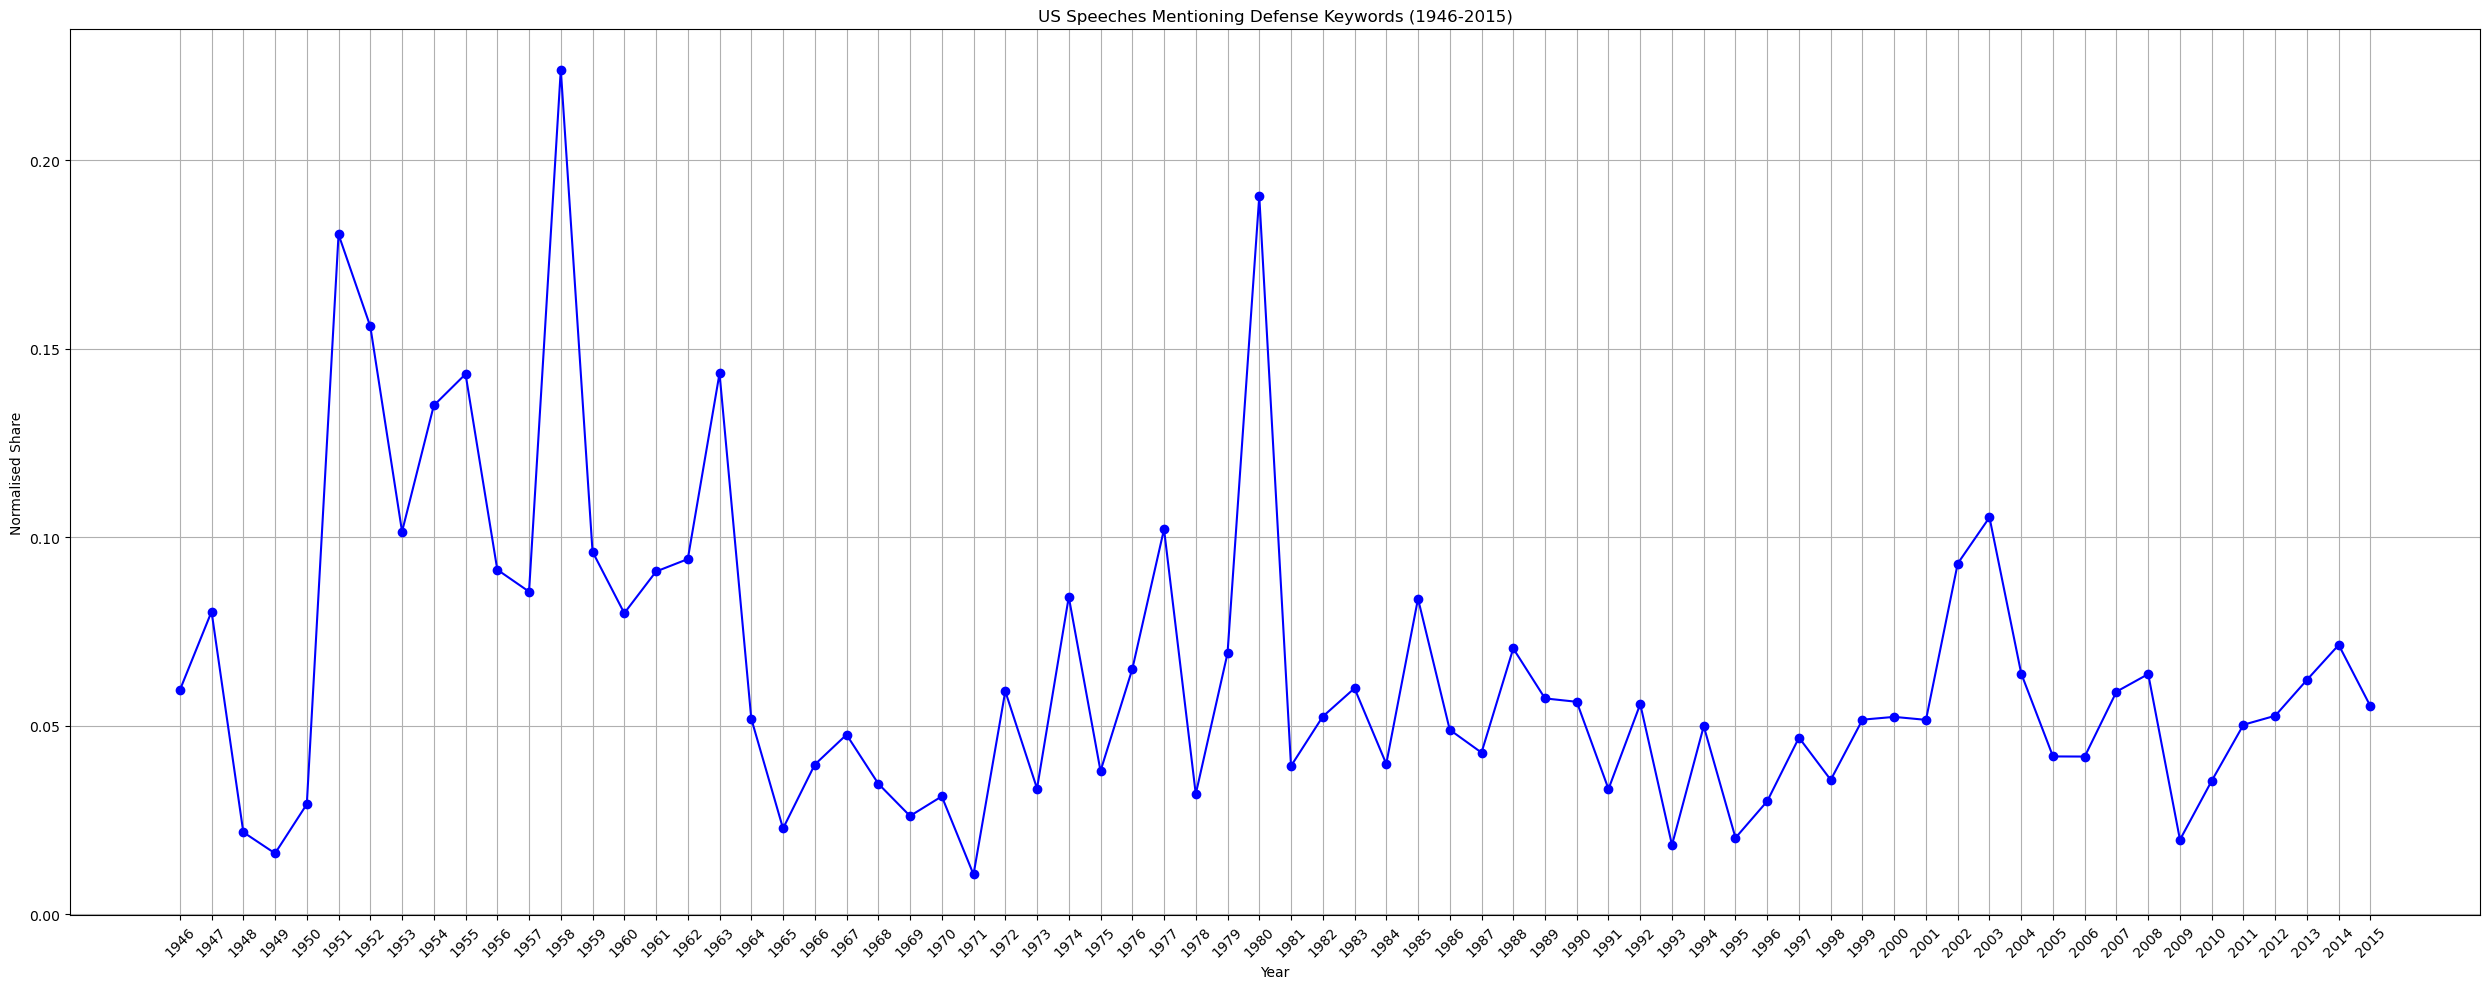

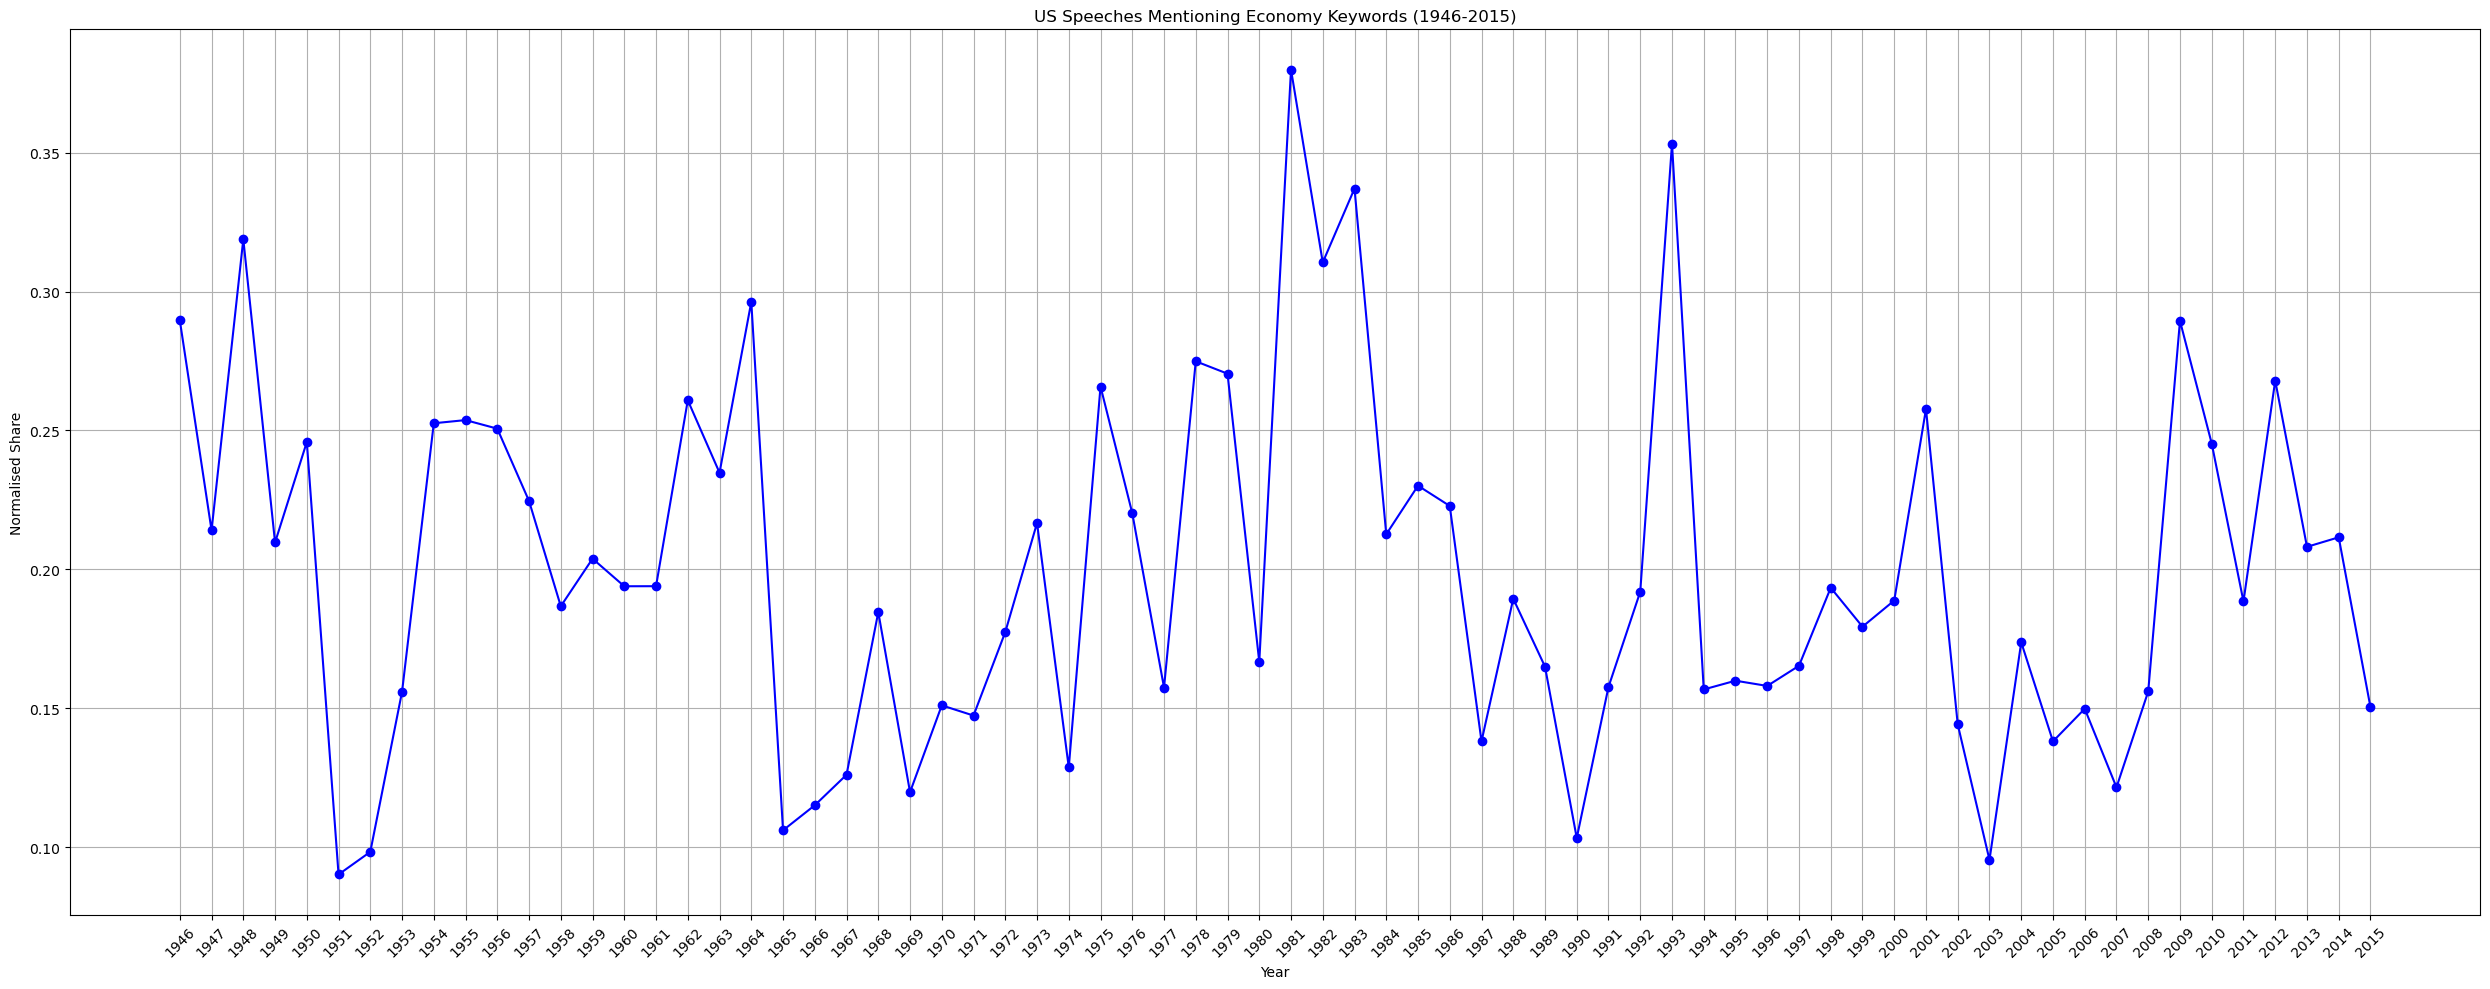

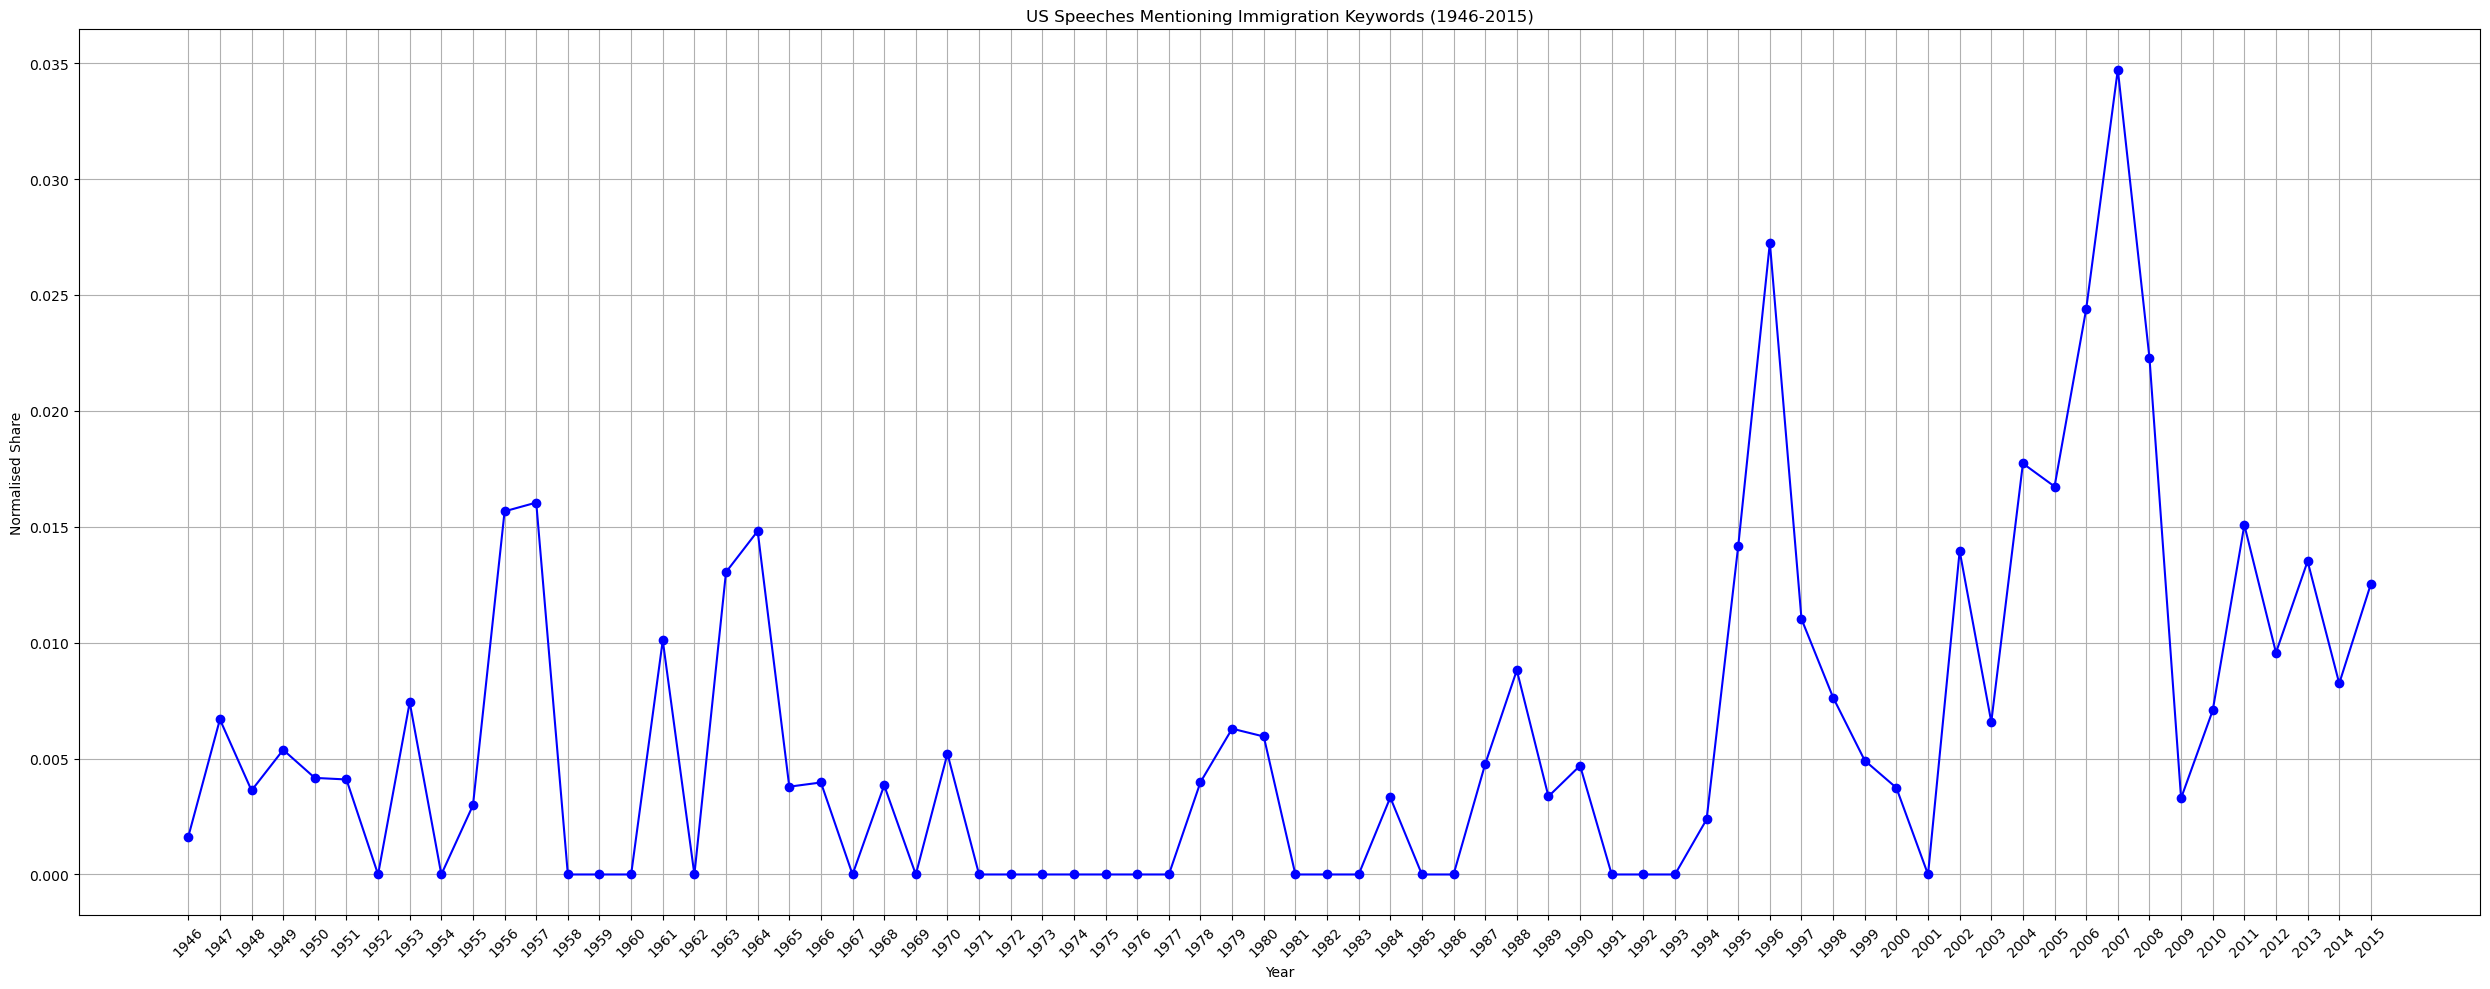

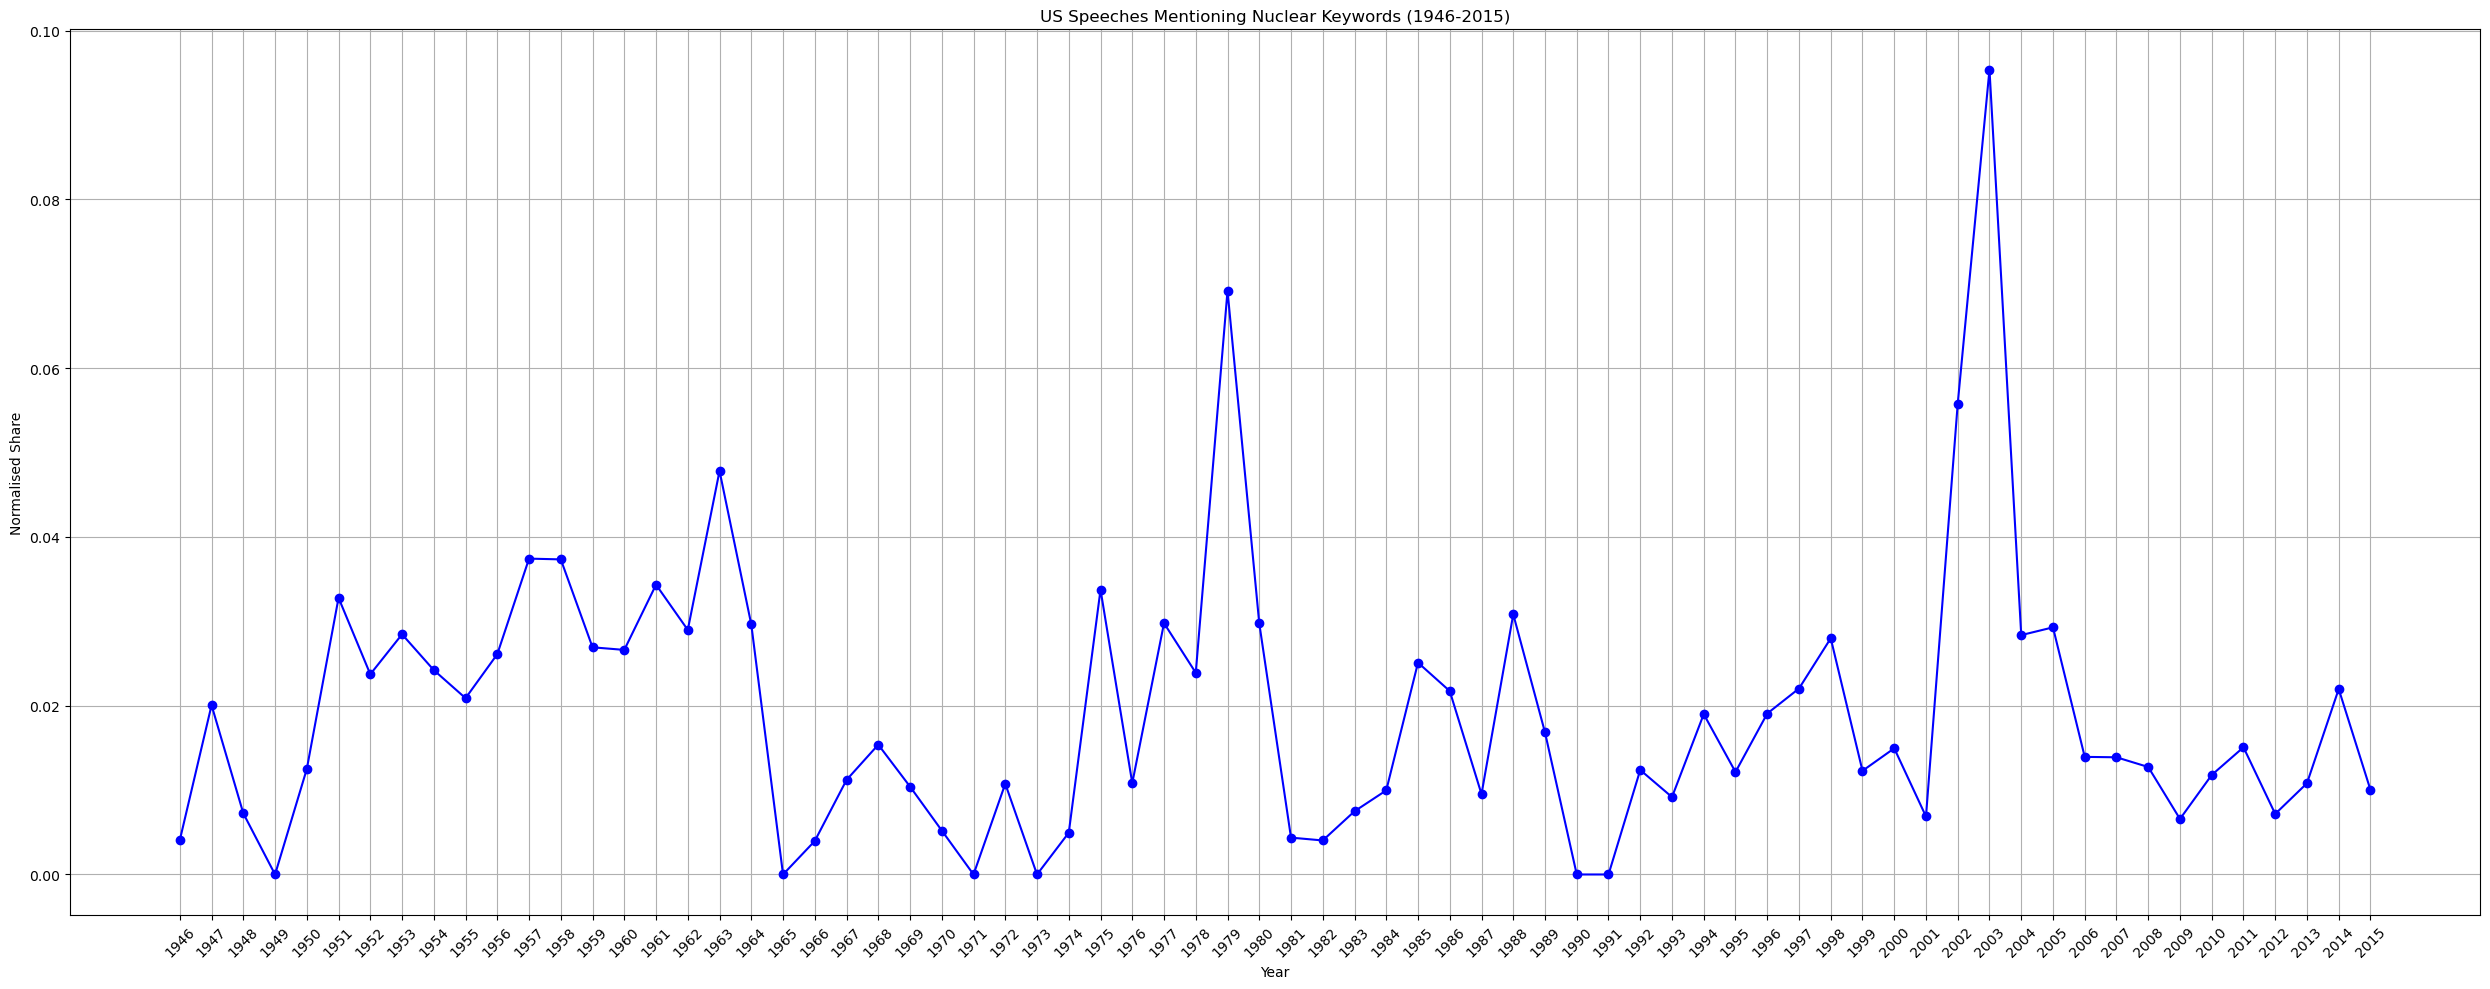

In [106]:
colors = ["blue","red", "green", "orange"]
categories = us_speeches_normalised["category"].unique()

for category in categories:
    df_cat = us_speeches_normalised[us_speeches_normalised["category"] == category]
    fig, ax = plt.subplots(figsize=(25, 10))
    ax.plot(df_cat["year"], df_cat["normalised_share"], marker="o", color="blue")
    ax.set_xlabel("Year")
    ax.set_ylabel("Normalised Share")
    ax.set_title(f"US Speeches Mentioning {category.capitalize()} Keywords ({YEAR_START}-{YEAR_END})")
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)
    plt.tight_layout()
    fig_path = os.path.join("..", "reports", "figures", f"us_{category}_speeches_plot.png")
    fig.savefig(fig_path)
    plt.show()

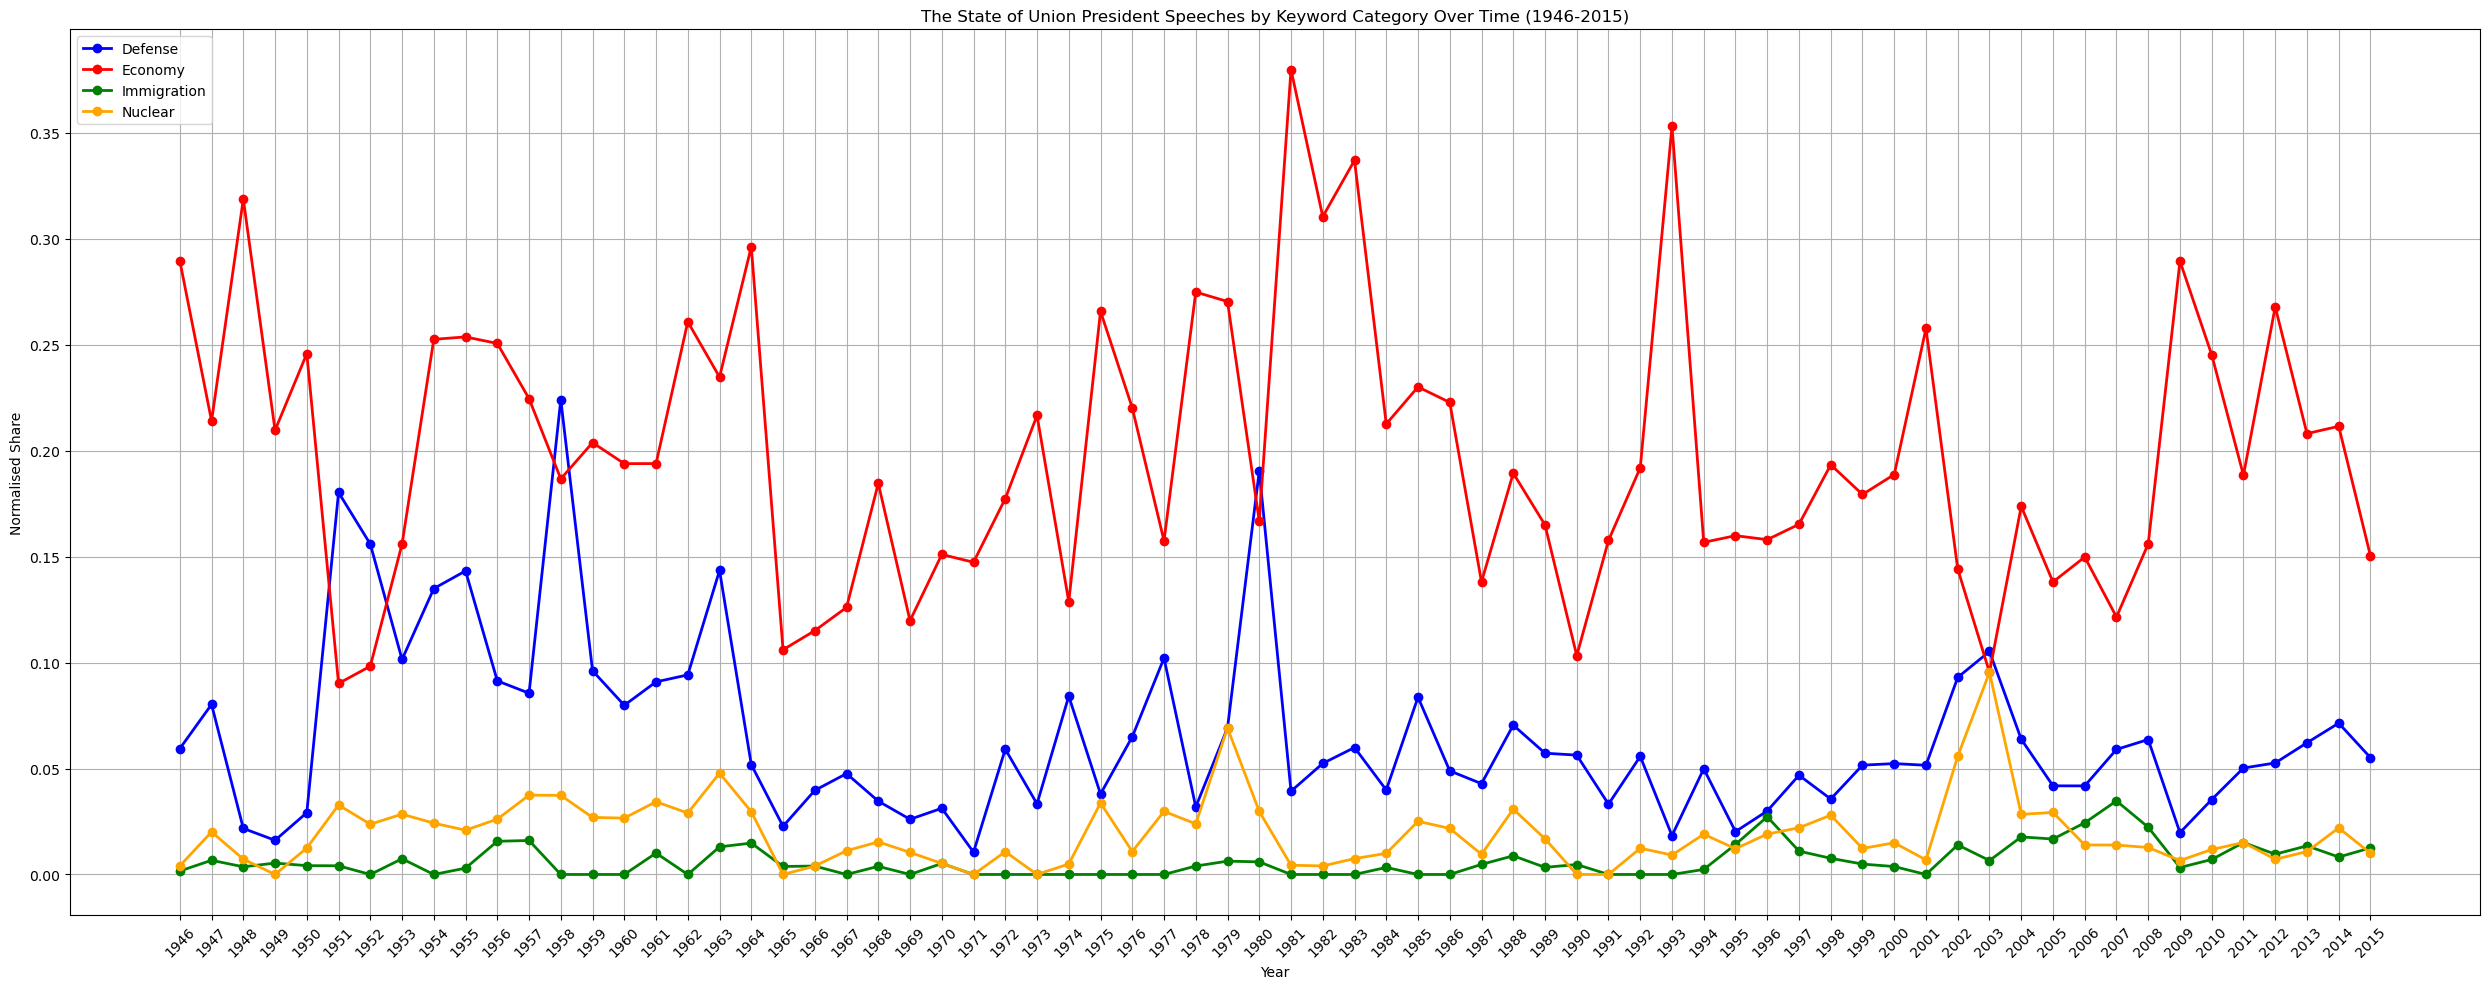

In [108]:
fig, ax = plt.subplots(figsize=(25, 10))

for category, color in zip(categories, colors):
    df_cat = us_speeches_normalised[us_speeches_normalised["category"] == category]
    ax.plot(df_cat["year"], df_cat["normalised_share"], label=category.capitalize(), color=color, marker="o", linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Normalised Share")
start = globals().get("YEAR_START")
end = globals().get("YEAR_END")
if start is None or end is None:
    years = us_speeches_normalised["year"]
    start, end = int(years.min()), int(years.max())
ax.set_title(f"The State of Union President Speeches by Keyword Category Over Time ({start}-{end})")
ax.set_xticks(range(start, end + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
ax.grid(True)
plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.
Extracting multi-word political phrases...


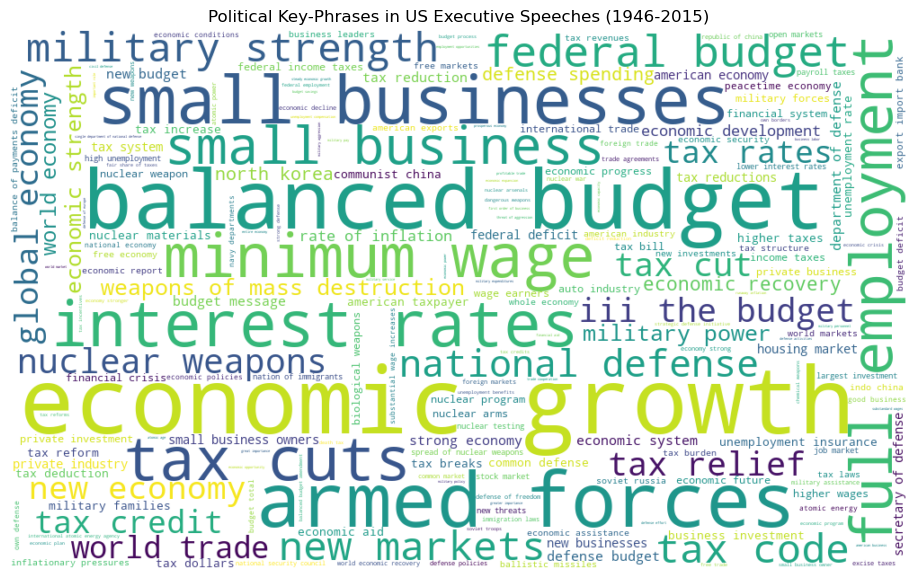

In [109]:
# 1.1.
%pip install wordcloud
import os
import re
import sys
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud
_CATEGORY_KEYWORDS = globals().get("CATEGORY_KEYWORDS")
sys.path.append("notebooks")
try:
	from keywords import CATEGORY_KEYWORDS as _CATEGORY_KEYWORDS
except Exception:
	_CATEGORY_KEYWORDS = {}
# expose as CATEGORY_KEYWORDS for the rest of the notebook
CATEGORY_KEYWORDS = _CATEGORY_KEYWORDS

# 1.2._Aillie's engine
YEAR_START, YEAR_END = 1946, 2015
TARGET_POS = {"NOUN", "PROPN", "ADJ"}
GLUE_WORDS = {"of", "the", "this", "these", "those", "our", "their", "his", "her", "on"}
GENERIC_NOUNS = {
    "number", "amount", "kind", "type", "part", "lot", "rest", "use",
    "case", "way", "fact", "thing", "point", "matter", "issue", "term",
}
MIN_DOC_FREQ = 2
nlp = spacy.load("en_core_web_sm")
ALL_POLITICAL_KEYWORDS = set().union(*CATEGORY_KEYWORDS.values())

# 2. Load and filter US data
us_speeches_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us = pd.read_csv(us_speeches_path)
df_us_range = df_us[(df_us['year'] >= YEAR_START) & (df_us['year'] <= YEAR_END)].copy()

# 3. Continuing same engine with phrase extraction
def extract_phrases(text):
    doc = nlp(str(text))
    tokens = [t for t in doc if not t.is_space and not t.is_punct]
    phrases = []
    i = 0
    while i < len(tokens):
        phrase_tokens = []
        j = i
        while j < len(tokens) and (
            tokens[j].pos_ in TARGET_POS
            or (tokens[j].text.lower() in GLUE_WORDS and phrase_tokens)
        ):
            phrase_tokens.append(tokens[j].text)
            j += 1

        while phrase_tokens and phrase_tokens[-1].lower() in GLUE_WORDS:
            phrase_tokens.pop()
            j -= 1

        if (
            len(phrase_tokens) >= 2
            and phrase_tokens[0].lower() not in GENERIC_NOUNS
            and phrase_tokens[-1].lower() not in GENERIC_NOUNS
        ):
            phrases.append(" ".join(phrase_tokens).lower())

        i = j if j > i else i + 1
    return phrases

def is_political(phrase):
    return any(keyword in phrase for keyword in ALL_POLITICAL_KEYWORDS)
phrase_counts = Counter()
phrase_doc_ids = defaultdict(set)

print("Extracting multi-word political phrases...")
for idx, row in df_us_range.iterrows():
    for phrase in extract_phrases(row["text"]):
        if not is_political(phrase):
            continue
        phrase_counts[phrase] += 1
        phrase_doc_ids[phrase].add(idx)

# 4. Build the dictionary strictly from the extracted phrases
final_frequencies = {
    phrase: count for phrase, count in phrase_counts.items()
    if len(phrase_doc_ids[phrase]) >= MIN_DOC_FREQ
}

# 5. Generate the word cloud using the actual phrase frequencies
if not final_frequencies:
	if "top_political_phrases_df" in globals() and not top_political_phrases_df.empty:
		final_frequencies = top_political_phrases_df.set_index("phrase")["total_count"].to_dict()
	elif "phrase_frequencies" in globals() and phrase_frequencies:
		final_frequencies = phrase_frequencies
	else:
		raise ValueError(
			"No phrase frequencies available for the word cloud. "
			"Check CATEGORY_KEYWORDS import and phrase extraction."
		)

political_wordcloud = WordCloud(
	width=1000,
	height=600,
	background_color="white",
	collocations=False
).generate_from_frequencies(final_frequencies)

# 6. Plot and save
plt.figure(figsize=(12, 7))
plt.imshow(political_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"Political Key-Phrases in US Executive Speeches ({YEAR_START}-{YEAR_END})")

wordcloud_fig_path = os.path.join("..", "reports", "figures", "us_speeches_phrases_wordcloud.png")
plt.savefig(wordcloud_fig_path, bbox_inches='tight')
plt.show()
